In [3]:
from abracalibra.forward_model import ForwardModel
from abracalibra.approximatebayesiancomputation import ApproximateBayesianComputation
from abracalibra.eki import EnsembleKalmanInversion
from abracalibra.history_matching import HistoryMatchingMultiTask
from abracalibra.summary import implausibility_univariate_distr
from torch.distributions import MultivariateNormal,Uniform


import torch
import matplotlib.pyplot as plt 

def sine_wave(x, a, b, c,d):
    return a * torch.sin(b * x + c)*torch.exp(-x/3)  + d

x = torch.linspace(0, 5, 10)
fixed_params = {'a': 1.0, 'c': 0.4,'d':0.3}
noise = 0.05

y = sine_wave(x, **fixed_params, b=0.78) + torch.randn_like(x)*noise

fwd = ForwardModel(sine_wave,vectorized=True, x=x, a=fixed_params['a'], c=fixed_params['c'], d=fixed_params['d'])

observables = MultivariateNormal(y, noise*noise*torch.eye(len(y)))

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
priors = {'b':Uniform(0,2)}
def summary(y,true_y):
    return torch.max(implausibility_univariate_distr(y,true_y),dim=-1).values 
hm = HistoryMatchingMultiTask(['b'],priors,observables,summary,ensemble_size=5,implausibility_cutoff=3,forward=fwd)
hm.calibrate(1)

Step 0 Loss: 1.141031265258789
Step 1 Loss: 1.1130552291870117
Step 2 Loss: 1.08573579788208
Step 3 Loss: 1.059117317199707
Step 4 Loss: 1.0331902503967285
Step 5 Loss: 1.0079295635223389
Step 6 Loss: 0.9832955002784729
Step 7 Loss: 0.9592260718345642
Step 8 Loss: 0.9356352090835571
Step 9 Loss: 0.9124467372894287
Step 10 Loss: 0.8895941376686096
Step 11 Loss: 0.8670172095298767
Step 12 Loss: 0.8446641564369202
Step 13 Loss: 0.822510302066803
Step 14 Loss: 0.800560474395752
Step 15 Loss: 0.7788172364234924
Step 16 Loss: 0.7572454810142517
Step 17 Loss: 0.7357770800590515
Step 18 Loss: 0.7143524289131165
Step 19 Loss: 0.6929706335067749
Step 20 Loss: 0.6716973781585693
Step 21 Loss: 0.650615930557251
Step 22 Loss: 0.6297985315322876
Step 23 Loss: 0.6092724800109863
Step 24 Loss: 0.5890136957168579
Step 25 Loss: 0.5689647197723389
Step 26 Loss: 0.5490507483482361
Step 27 Loss: 0.529186487197876
Step 28 Loss: 0.5092569589614868
Step 29 Loss: 0.48911744356155396
Step 30 Loss: 0.46864566206

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/var/folders/58/1mynp4bn1pg61mc1j6p3nnxc0000gp/T/ipykernel_91906/2443455306.py:17: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel("$\omega$")
/var/folders/58/1mynp4bn1pg61mc1j6p3nnxc0000gp/T/ipykernel_91906/2443455306.py:28: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel("$\omega$")


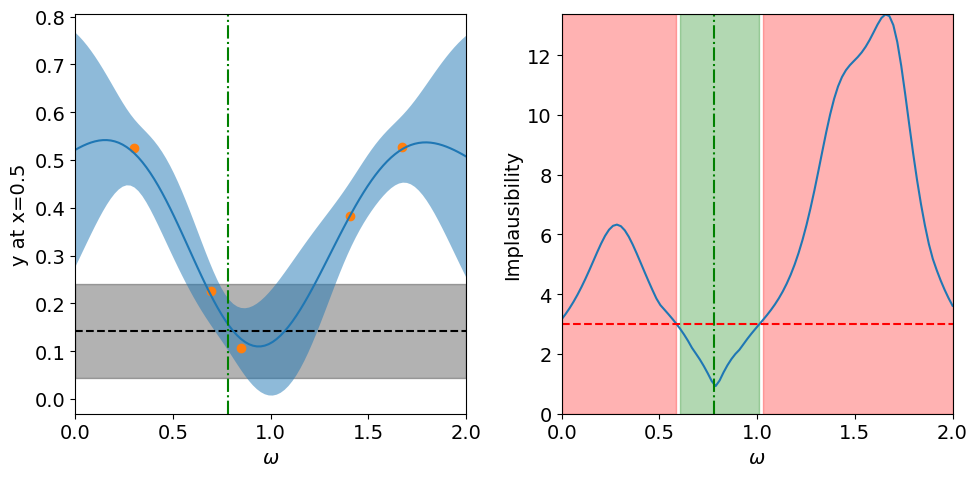

In [5]:
em = hm.emulators[hm.current_wave - 1]
em.eval()
plt.rcParams.update({'font.size': 14})
a = torch.linspace(0, 2, 100)
imp = hm.implausibility(a,wave=hm.current_wave - 1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
plot_dim = 8
with torch.no_grad():
    pred_val = em(a)
    lower,upper = pred_val.confidence_region()
    ax1.axhline(y=y[plot_dim],color='black',linestyle='--')
    ax1.fill_between(a,y[plot_dim] - 1.96*noise,y[plot_dim] + 1.96*noise,alpha=0.3,color='black')
    ax1.set_xlim(0,2)
    ax1.plot(a,pred_val.mean[:,plot_dim])
    ax1.fill_between(a,lower[:,plot_dim],upper[:,plot_dim],alpha=0.5)
    ax1.scatter(hm.params[:,:].view(-1,1),hm.results[:,:,plot_dim].view(-1,1))
    ax1.set_xlabel("$\omega$")
    ax1.axvline(0.78,color='green',linestyle='-.')
    ax1.set_ylabel("y at x=0.5")

    ax2.fill_between(a,torch.zeros_like(a),torch.ones_like(a)*imp.max(),alpha=0.3,color='green',where=imp<3)
    ax2.fill_between(a,torch.zeros_like(a),torch.ones_like(a)*imp.max(),alpha=0.3,color='red',where=imp>=3)
    ax2.plot(a,imp)
    ax2.set_xlim(0,2)
    ax2.set_ylim(0,imp.max())
    ax2.axvline(0.78,color='green',linestyle='-.')
    ax2.axhline(3,color='red',linestyle='--')
    ax2.set_xlabel("$\omega$")
    ax2.set_ylabel("Implausibility")

fig.tight_layout()
fig.savefig("history_matching.png",dpi=300)



In [37]:
def harder_sine_wave(x,y,a,b,c,d,e):
    return a * torch.sin(b * x + c*y + d)  + e

x = torch.linspace(0, 5, 5)
y = torch.linspace(0,5, 5)
X,Y = torch.meshgrid(x,y,indexing='ij')

fixed_params = {
    'a': 1.0,
    'b': 0.78,
    'c': 0.4,
    'd': 0.3,
    'e': 0.5
}

noise = 0.05    
fwd = ForwardModel(harder_sine_wave,vectorized=True, x=X.ravel(), y=Y.ravel(), a=fixed_params['a'], d=fixed_params['d'], e=fixed_params['e'])
observables = MultivariateNormal(fwd(torch.tensor([fixed_params['b'],fixed_params['c']])), noise*noise*torch.eye(X.numel()))
parameters = ['b','c']
priors = {'b':Uniform(0,1),'c':Uniform(0,1)}
def summary(y,true_y):
    return torch.max(implausibility_univariate_distr(y,true_y),dim=-1).values 
hm = HistoryMatchingMultiTask(parameters,priors,observables,summary,ensemble_size=20,implausibility_cutoff=3,forward=fwd)
hm.calibrate(1)

Step 0 Loss: 1.053563117980957
Step 1 Loss: 1.0336277484893799
Step 2 Loss: 1.0142019987106323
Step 3 Loss: 0.9952502250671387
Step 4 Loss: 0.9766541719436646
Step 5 Loss: 0.9582973122596741
Step 6 Loss: 0.9401144981384277
Step 7 Loss: 0.9220858216285706
Step 8 Loss: 0.9042045474052429
Step 9 Loss: 0.886454701423645
Step 10 Loss: 0.8688091039657593
Step 11 Loss: 0.8512409925460815
Step 12 Loss: 0.8337381482124329
Step 13 Loss: 0.8163058757781982
Step 14 Loss: 0.798963725566864
Step 15 Loss: 0.7817344069480896
Step 16 Loss: 0.7646347880363464
Step 17 Loss: 0.7476701140403748
Step 18 Loss: 0.730836033821106
Step 19 Loss: 0.7141252160072327
Step 20 Loss: 0.6975295543670654
Step 21 Loss: 0.6810412406921387
Step 22 Loss: 0.6646558046340942
Step 23 Loss: 0.6483720541000366
Step 24 Loss: 0.6321925520896912
Step 25 Loss: 0.616124153137207
Step 26 Loss: 0.600168764591217
Step 27 Loss: 0.5843175053596497
Step 28 Loss: 0.5685415863990784
Step 29 Loss: 0.5527957677841187
Step 30 Loss: 0.5370298027

torch.no_grad() active: False
gpytorch.settings.fast_pred_var active: False


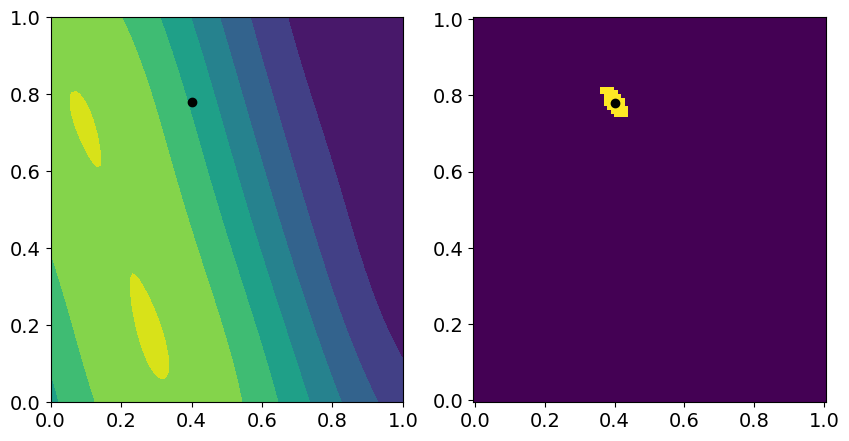

In [38]:
import gpytorch


em = hm.emulators[hm.current_wave - 1]
em.eval()
a = torch.linspace(0, 1, 100)
b = torch.linspace(0, 1, 100)
A,B = torch.meshgrid(a,b,indexing='ij')
thetas = torch.stack([A,B],dim=-1).view(-1,2)
imp = hm.implausibility(thetas,wave=hm.current_wave - 1)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
with torch.no_grad(),gpytorch.settings.fast_pred_var():
    pred_val = em(thetas).mean.view(100,100,hm.number_of_observables)
    ax1.contourf(B,A,pred_val[:,:,8])
    ax1.scatter([fixed_params['c']],[fixed_params['b']],color='black')
    ax2.pcolormesh(B,A,imp.view(100,100) < 3 )
    ax2.scatter([fixed_params['c']],[fixed_params['b']],color='black')

   